
# Nearest Neighbors Classification

This example shows how to use :class:`~sklearn.neighbors.KNeighborsClassifier`.
We train such a classifier on the iris dataset and observe the difference of the
decision boundary obtained with regards to the parameter `weights`.


In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

## Load the data

In this example, we use the iris dataset. We split the data into a train and test
dataset.



### 1. Carga y preparación del conjunto de datos Iris

En esta celda, importamos y preparamos el popular conjunto de datos **Iris**, un clásico en el aprendizaje automático para problemas de clasificación.

* **`from sklearn.datasets import load_iris`**: Importamos la función para cargar el dataset Iris.
* **`iris = load_iris(as_frame=True)`**: Cargamos el conjunto de datos en un formato de `DataFrame` de pandas (`as_frame=True`), lo cual facilita su manipulación.
* **`X = iris.data[["sepal length (cm)", "sepal width (cm)"]]`**: Seleccionamos solo dos de las cuatro características disponibles (`longitud y anchura del sépalo`) para crear nuestras variables de entrada (`X`). Elegir solo dos características nos permitirá visualizar los resultados en un gráfico 2D más adelante.
* **`y = iris.target`**: La variable objetivo (`y`) contiene las etiquetas de las clases (los tipos de flores: *setosa*, *versicolor* o *virginica*).
* **`train_test_split(...)`**: Dividimos los datos en conjuntos de entrenamiento y prueba.
    * **`stratify=y`**: Este parámetro asegura que la proporción de clases en los conjuntos de entrenamiento y prueba sea la misma que en el conjunto de datos original. Esto es crucial en datasets con clases desbalanceadas para evitar sesgos.
    * **`random_state=0`**: Garantiza que la división sea la misma cada vez que se ejecute la celda, haciendo que los resultados sean **reproducibles**.

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
X = iris.data[["sepal length (cm)", "sepal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

## K-nearest neighbors classifier

We want to use a k-nearest neighbors classifier considering a neighborhood of 11 data
points. Since our k-nearest neighbors model uses euclidean distance to find the
nearest neighbors, it is therefore important to scale the data beforehand. Refer to
the example entitled
`sphx_glr_auto_examples_preprocessing_plot_scaling_importance.py` for more
detailed information.

Thus, we use a :class:`~sklearn.pipeline.Pipeline` to chain a scaler before to use
our classifier.



### 2. Creación de un Pipeline con KNN

En esta celda, utilizamos un **Pipeline** de `scikit-learn`. Un pipeline es una herramienta que encadena múltiples pasos de un flujo de trabajo de aprendizaje automático, lo que garantiza que los datos se preprocesen y se entrenen de forma consistente. Esto es especialmente útil para evitar la fuga de datos y simplificar el código.

* **`from sklearn.pipeline import Pipeline`**: Importamos la clase `Pipeline`.
* **`from sklearn.preprocessing import StandardScaler`**: Importamos el escalador que utilizamos en el ejercicio anterior.
* **`from sklearn.neighbors import KNeighborsClassifier`**: Importamos el clasificador KNN.
* **`clf = Pipeline(steps=[...])`**: Creamos una instancia del `Pipeline`. Le pasamos una lista de tuplas, donde cada tupla representa un paso:
    1.  `("scaler", StandardScaler())`: El primer paso se llama "scaler" y utiliza un `StandardScaler` para estandarizar los datos.
    2.  `("knn", KNeighborsClassifier(n_neighbors=11))`: El segundo paso se llama "knn" y utiliza un `KNeighborsClassifier` con **11 vecinos** (`n_neighbors=11`).

Con este `Pipeline`, cuando entrenemos el modelo, los datos pasarán automáticamente por el escalado y luego se usarán para entrenar el clasificador, todo en un solo paso.

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=11))]
)

## Decision boundary

Now, we fit two classifiers with different values of the parameter
`weights`. We plot the decision boundary of each classifier as well as the original
dataset to observe the difference.



### 3. Visualización de las fronteras de decisión de KNN 

Esta celda de código es avanzada porque visualiza cómo el algoritmo **KNN toma decisiones** en función de los pesos que asigna a sus vecinos. La clave aquí es entender que los vecinos más cercanos no siempre tienen el mismo "voto".

Este código genera dos gráficos lado a lado:
* El gráfico de la **izquierda** usa un peso `uniform` (uniforme).
* El gráfico de la **derecha** usa un peso `distance` (distancia).

#### Explicación

1.  **`from sklearn.inspection import DecisionBoundaryDisplay`**: Importa una herramienta de Scikit-learn que simplifica la creación de gráficos de fronteras de decisión. Es lo que dibuja las áreas de colores en el fondo.
2.  **`_, axs = plt.subplots(ncols=2, figsize=(12, 5))`**: Crea una figura con dos subplots (gráficos) en una sola fila. `axs` es un arreglo que contiene los dos ejes del gráfico, uno para cada subplot.
3.  **`for ax, weights in zip(axs, ("uniform", "distance")):`**: Este es un bucle que se ejecuta dos veces.
    * En la primera iteración, `ax` apunta al subplot de la izquierda y `weights` es `"uniform"`.
    * En la segunda, `ax` apunta al de la derecha y `weights` es `"distance"`.
4.  **`clf.set_params(knn__weights=weights).fit(X_train, y_train)`**: Aquí es donde se cambia el peso del clasificador dentro del `Pipeline`.
    * `set_params()` modifica un parámetro de cualquier paso en el pipeline.
    * `knn__weights` apunta específicamente al parámetro `weights` del clasificador KNN (el que nombramos `"knn"`). Esto le dice al clasificador cómo debe ponderar los votos de los vecinos:
        * **`"uniform"`**: Todos los `k` vecinos tienen el mismo peso en la votación. Es el comportamiento por defecto.
        * **`"distance"`**: El voto de cada vecino se pondera por la inversa de su distancia. Es decir, los vecinos **más cercanos** tienen un mayor impacto en la decisión final que los vecinos más lejanos.
    * `.fit()` entrena el modelo de nuevo con el nuevo parámetro.
5.  **`disp = DecisionBoundaryDisplay.from_estimator(...)`**: Dibuja la frontera de decisión.
    * Usa el clasificador `clf` que acabamos de entrenar.
    * Le pasa los datos de prueba (`X_test`).
    * **`response_method="predict"`**: Le dice a la función que use las predicciones de clase para colorear el gráfico.
    * `xlabel`, `ylabel` y `title`: Añaden etiquetas al gráfico para que sea más legible.
6.  **`scatter = disp.ax_.scatter(...)`**: Dibuja los puntos de datos reales del dataset Iris sobre la frontera de decisión. Cada punto tiene el color de su clase real.
7.  **`disp.ax_.legend(...)`**: Crea la leyenda para que sepas qué color corresponde a cada tipo de flor (setosa, versicolor, virginica).
8.  **`plt.show()`**: Muestra el gráfico final.

#### ¿Qué muestra el gráfico?

Observa las diferencias entre ambos gráficos. En el gráfico con pesos **uniformes**, las fronteras de decisión pueden ser más irregulares, ya que todos los vecinos más cercanos tienen la misma influencia. En el gráfico con pesos **ponderados por la distancia**, las fronteras de decisión son a menudo más suaves, ya que los puntos que están más cerca de la frontera tienen una influencia más significativa. El gráfico demuestra visualmente cómo un simple cambio en un hiperparámetro puede alterar la forma en que el modelo clasifica los datos.

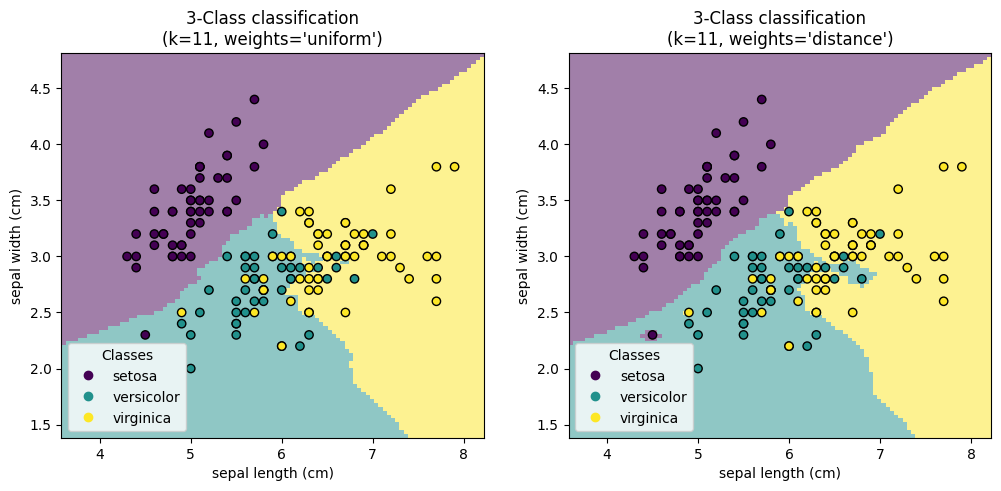

In [4]:
import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay

_, axs = plt.subplots(ncols=2, figsize=(12, 5))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()

### Interpretación de los Gráficos

Este gráfico visualiza cómo el algoritmo **K-Nearest Neighbors (KNN)** clasifica el conjunto de datos Iris. Muestra las **fronteras de decisión** del modelo al usar diferentes estrategias de ponderación para los vecinos: `uniform` y `distance`.

---

### Análisis de la visualización

Ambos gráficos muestran la clasificación de las flores de Iris en base a dos de sus características: la **longitud del sépalo** y el **ancho del sépalo**. Los puntos son las flores del conjunto de datos, coloreadas según su tipo (clase).

* **Puntos morados**: Flores de tipo *setosa*.
* **Puntos turquesa**: Flores de tipo *versicolor*.
* **Puntos amarillos**: Flores de tipo *virginica*.

El color del **fondo** de cada región representa la clase que el modelo predice para cualquier punto que caiga en esa área. La **frontera de decisión** es la línea donde el color del fondo cambia.

---

### 1. Gráfico de la izquierda: Pesos `uniform` (Uniformes)

* En este gráfico, todos los **11 vecinos más cercanos** de un punto tienen la misma "voz" en la decisión de la clase.
* Las fronteras de decisión son más **irregulares** y **fragmentadas**. Esto se debe a que un punto más lejano puede tener la misma influencia que uno más cercano si ambos están entre los 11 vecinos más próximos.
* Puedes notar que algunas áreas pequeñas de una clase se infiltran en las regiones de otras clases.

---

### 2. Gráfico de la derecha: Pesos `distance` (Distancia)

* En este gráfico, el voto de cada uno de los **11 vecinos** está **ponderado por la inversa de su distancia** al punto que se está clasificando. Los puntos más cercanos tienen un voto más fuerte.
* Las fronteras de decisión son más **suaves** y **fluidas**. El modelo se vuelve más sensible a los puntos que están muy cerca de él, lo que reduce la influencia de los puntos lejanos y, por lo tanto, la "fragmentación" de las fronteras.

---

### Conclusión

La principal diferencia visual entre ambos gráficos es la **suavidad de las fronteras de decisión**. El gráfico de la derecha, que usa pesos basados en la distancia, crea límites de clasificación más lógicos y limpios, lo que a menudo refleja un modelo más generalizable y con mejor desempeño en la práctica, al darle mayor importancia a los vecinos inmediatos.